# Analisis Numerik Gerai Donat

Analisis ini membahas hubungan **jumlah penjualan dengan revenue** pada lima gerai donat.
Tahapan yang dilakukan adalah membuat scatter plot, membangun regresi linear, kemudian mencari **Break Even Point (BEP)** dengan metode Bisection.

Link Github: https://github.com/evaagista/Analisis-Numerik

## 1. Import Library

Library yang digunakan yaitu Pandas dan NumPy untuk pengolahan data, Matplotlib untuk grafik, serta `LinearRegression` untuk regresi linear.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## 2. Membaca Dataset


In [2]:
from google.colab import files

uploaded = files.upload()
nama_file = next(iter(uploaded))

df = pd.read_csv(nama_file)
df.head()

Saving sintesis_data_donat_harian.csv to sintesis_data_donat_harian.csv


,Tanggal,Gerai,Harga Jual (Rp),Jumlah Terjual (Unit),Pendapatan Kotor (Rp),Biaya Variabel (Rp),Fixed Cost Harian (Rp),Balance (Rp)
0,2026-01-01,Gerai A,25000,87,2175000,739500,1683333,-247833
1,2026-01-02,Gerai A,25000,81,2025000,688500,1683333,-346833
2,2026-01-03,Gerai A,25000,110,2750000,935000,1683333,131667
3,2026-01-04,Gerai A,25000,119,2975000,1011500,1683333,280167
4,2026-01-05,Gerai A,25000,94,2350000,799000,1683333,-132333


Dataset berisi data harian dari lima gerai, yaitu Gerai A sampai Gerai E. Beberapa kolom yang digunakan dalam analisis adalah jumlah produk terjual, pendapatan kotor, biaya variabel, dan fixed cost harian.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Tanggal                 450 non-null    object
 1   Gerai                   450 non-null    object
 2   Harga Jual (Rp)         450 non-null    int64 
 3   Jumlah Terjual (Unit)   450 non-null    int64 
 4   Pendapatan Kotor (Rp)   450 non-null    int64 
 5   Biaya Variabel (Rp)     450 non-null    int64 
 6   Fixed Cost Harian (Rp)  450 non-null    int64 
 7   Balance (Rp)            450 non-null    int64 
dtypes: int64(6), object(2)
memory usage: 28.3+ KB


In [4]:
df.groupby("Gerai").agg({
    "Jumlah Terjual (Unit)": ["min", "max", "mean"],
    "Pendapatan Kotor (Rp)": ["min", "max", "mean"]
})

Jumlah Terjual (Unit)                  Pendapatan Kotor (Rp)           \
                          min  max        mean                   min      max   
Gerai                                                                           
Gerai A                    81  131   99.100000               2025000  3275000   
Gerai B                   435  710  527.500000               3480000  5680000   
Gerai C                   220  522  328.933333               2420000  5742000   
Gerai D                   103  223  149.833333               2060000  4460000   
Gerai E                   153  332  226.644444               2295000  4980000   

                       
                 mean  
Gerai                  
Gerai A  2.477500e+06  
Gerai B  4.220000e+06  
Gerai C  3.618267e+06  
Gerai D  2.996667e+06  
Gerai E  3.399667e+06

## 3. Plot Jumlah Penjualan vs Revenue

Scatter plot digunakan untuk melihat pola hubungan antara volume penjualan dan revenue. Setiap titik menunjukkan satu pengamatan harian pada suatu gerai.

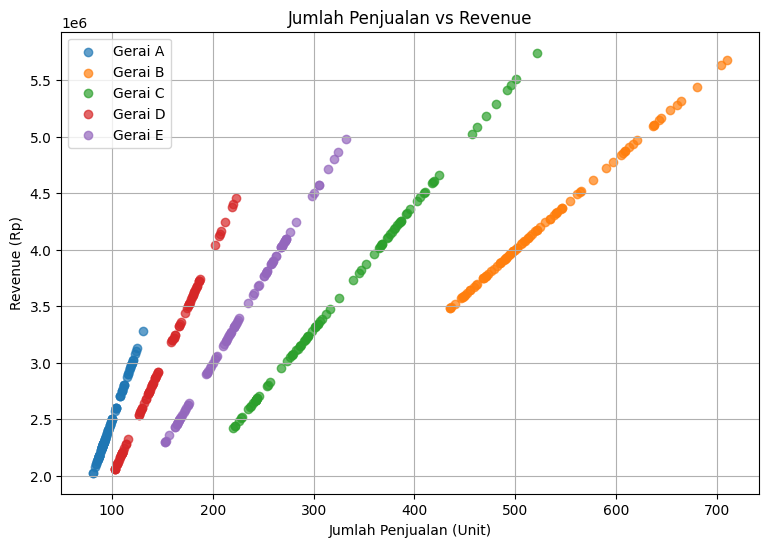

In [5]:
plt.figure(figsize=(9, 6))

for gerai in df["Gerai"].unique():
    data = df[df["Gerai"] == gerai]
    plt.scatter(
        data["Jumlah Terjual (Unit)"],
        data["Pendapatan Kotor (Rp)"],
        label=gerai,
        alpha=0.7
    )

plt.xlabel("Jumlah Penjualan (Unit)")
plt.ylabel("Revenue (Rp)")
plt.title("Jumlah Penjualan vs Revenue")
plt.legend()
plt.grid(True)
plt.show()

Dari scatter plot, titik data tiap gerai cenderung bergerak naik ketika jumlah penjualan bertambah. Artinya, semakin banyak produk yang terjual, revenue yang diperoleh juga cenderung meningkat. Pola yang relatif lurus membuat regresi linear cukup sesuai untuk menggambarkan tren revenue.

## 4. Regresi Linear

Model yang digunakan adalah:

$$
y = ax + b
$$

`x` adalah jumlah penjualan, sedangkan `y` adalah revenue. Nilai `a` menunjukkan perubahan revenue untuk setiap tambahan satu unit penjualan, sedangkan `b` adalah intercept model.

In [6]:
hasil_regresi = []

for gerai in df["Gerai"].unique():
    data = df[df["Gerai"] == gerai]

    X = data[["Jumlah Terjual (Unit)"]]
    y = data["Pendapatan Kotor (Rp)"]

    model = LinearRegression()
    model.fit(X, y)

    hasil_regresi.append({
        "Gerai": gerai,
        "Slope": model.coef_[0],
        "Intercept": model.intercept_,
        "R2": model.score(X, y)
    })

hasil_regresi = pd.DataFrame(hasil_regresi)
hasil_regresi

,Gerai,Slope,Intercept,R2
0,Gerai A,25000.0,-4.656613e-10,1.0
1,Gerai B,8000.0,0.000000e+00,1.0
2,Gerai C,11000.0,4.656613e-10,1.0
3,Gerai D,20000.0,-9.313226e-10,1.0
4,Gerai E,15000.0,-4.656613e-10,1.0


In [7]:
for _, r in hasil_regresi.iterrows():
    print(
        f"{r['Gerai']}: Revenue = "
        f"{r['Slope']:.2f}x + {r['Intercept']:.2f}, "
        f"R² = {r['R2']:.4f}"
    )

Gerai A: Revenue = 25000.00x + -0.00, R² = 1.0000
Gerai B: Revenue = 8000.00x + 0.00, R² = 1.0000
Gerai C: Revenue = 11000.00x + 0.00, R² = 1.0000
Gerai D: Revenue = 20000.00x + -0.00, R² = 1.0000
Gerai E: Revenue = 15000.00x + -0.00, R² = 1.0000


Hasil regresi digunakan untuk melihat seberapa kuat hubungan volume penjualan dengan revenue. Nilai R² yang semakin mendekati 1 menunjukkan bahwa variasi revenue pada data tersebut semakin banyak dapat dijelaskan oleh jumlah penjualan melalui model linear.

### Grafik Garis Regresi

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


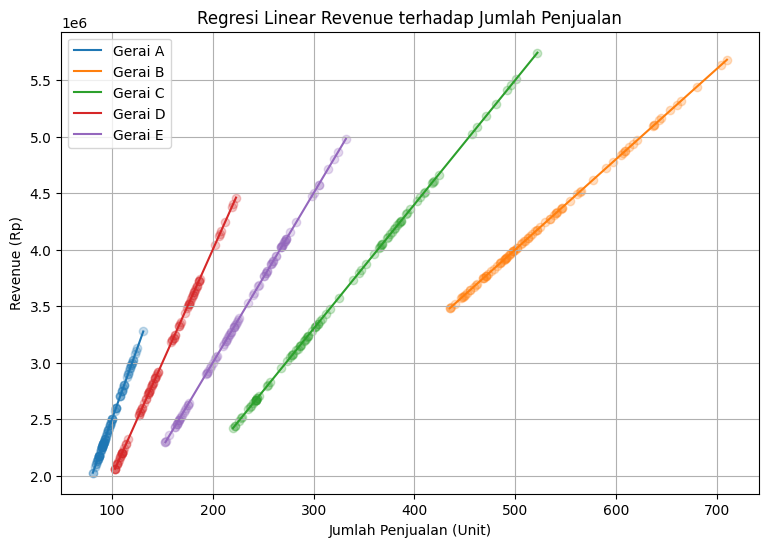

In [8]:
plt.figure(figsize=(9, 6))

for gerai in df["Gerai"].unique():
    data = df[df["Gerai"] == gerai]

    X = data[["Jumlah Terjual (Unit)"]]
    y = data["Pendapatan Kotor (Rp)"]

    model = LinearRegression()
    model.fit(X, y)

    x_line = np.linspace(X.min().iloc[0], X.max().iloc[0], 100).reshape(-1, 1)
    y_line = model.predict(x_line)

    plt.scatter(X, y, alpha=0.25)
    plt.plot(x_line, y_line, label=gerai)

plt.xlabel("Jumlah Penjualan (Unit)")
plt.ylabel("Revenue (Rp)")
plt.title("Regresi Linear Revenue terhadap Jumlah Penjualan")
plt.legend()
plt.grid(True)
plt.show()

Garis regresi memperlihatkan arah tren revenue untuk masing-masing gerai. Karena garis cenderung meningkat, tambahan volume penjualan berkaitan dengan kenaikan revenue. Kemiringan garis juga berbeda karena karakteristik harga dan data penjualan setiap gerai tidak sama.

## 5. Menentukan Fungsi BEP

BEP dicari ketika **revenue sama dengan total cost**. Pada bagian ini revenue menggunakan hasil regresi:

$$
R(x) = ax+b
$$

Total cost dimodelkan sebagai:

$$
TC(x) = VCx+FC
$$

Sehingga fungsi yang dicari akarnya adalah:

$$
f(x)=R(x)-TC(x)
$$

Saat `f(x) = 0`, revenue dan total cost sama sehingga diperoleh titik impas.

In [9]:
# Menghitung biaya variabel rata-rata per unit dan fixed cost
biaya = []

for gerai in df["Gerai"].unique():
    data = df[df["Gerai"] == gerai]

    vc_per_unit = (
        data["Biaya Variabel (Rp)"].sum()
        / data["Jumlah Terjual (Unit)"].sum()
    )

    biaya.append({
        "Gerai": gerai,
        "VC per Unit": vc_per_unit,
        "Fixed Cost": data["Fixed Cost Harian (Rp)"].iloc[0]
    })

biaya = pd.DataFrame(biaya)
biaya

,Gerai,VC per Unit,Fixed Cost
0,Gerai A,8500.0,1683333
1,Gerai B,4160.0,733333
2,Gerai C,4840.0,1733333
3,Gerai D,7200.0,2666666
4,Gerai E,6300.0,800000


Biaya variabel per unit diperoleh dari total biaya variabel dibagi total unit terjual. Nilai ini kemudian dipakai sebagai pendekatan biaya variabel untuk setiap tambahan satu unit penjualan.

## 6. Pencarian Akar dengan Metode Bisection

Metode Bisection mencari akar dengan membagi interval menjadi dua secara berulang. Syarat awalnya adalah nilai fungsi pada batas bawah dan batas atas mempunyai tanda yang berbeda.

Proses dihentikan ketika nilai fungsi sudah cukup dekat dengan nol atau panjang interval sudah lebih kecil dari toleransi.

In [10]:
def bisection(f, a, b, tol=1e-6, max_iter=100):
    fa = f(a)
    fb = f(b)

    if fa * fb > 0:
        raise ValueError("Interval awal tidak mengandung akar.")

    for i in range(max_iter):
        c = (a + b) / 2
        fc = f(c)

        if abs(fc) < tol or (b - a) / 2 < tol:
            return c, i + 1

        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc

    return c, max_iter

### Mencari BEP masing-masing gerai

Agar interval tidak ditentukan secara asal, batas atas akan diperbesar sampai fungsi memiliki tanda yang berbeda dari `f(0)`. Setelah interval ditemukan, Bisection digunakan untuk mendapatkan akar.

In [11]:
hasil_bep = []

for _, r in hasil_regresi.iterrows():
    gerai = r["Gerai"]

    vc = biaya.loc[biaya["Gerai"] == gerai, "VC per Unit"].iloc[0]
    fc = biaya.loc[biaya["Gerai"] == gerai, "Fixed Cost"].iloc[0]

    a = r["Slope"]
    b = r["Intercept"]

    def f(x, a=a, b=b, vc=vc, fc=fc):
        return (a * x + b) - (vc * x + fc)

    batas_b = 100

    while f(0) * f(batas_b) > 0 and batas_b < 100000:
        batas_b *= 2

    if f(0) * f(batas_b) > 0:
        print(f"{gerai}: akar tidak ditemukan pada rentang yang dicoba.")
        continue

    bep, iterasi = bisection(f, 0, batas_b)

    hasil_bep.append({
        "Gerai": gerai,
        "BEP (Unit)": bep,
        "BEP Dibulatkan": np.ceil(bep),
        "Iterasi": iterasi
    })

hasil_bep = pd.DataFrame(hasil_bep)
hasil_bep

,Gerai,BEP (Unit),BEP Dibulatkan,Iterasi
0,Gerai A,102.020182,103.0,28
1,Gerai B,190.972135,191.0,28
2,Gerai C,281.385227,282.0,29
3,Gerai D,208.333281,209.0,29
4,Gerai E,91.954023,92.0,27


Nilai BEP dapat berbentuk desimal karena diperoleh dari proses numerik. Dalam praktiknya, jumlah produk harus berupa bilangan bulat, sehingga nilai BEP dibulatkan ke atas. Artinya, gerai perlu mencapai setidaknya jumlah unit tersebut agar melewati titik impas berdasarkan model yang digunakan.

## 7. Visualisasi Revenue, Total Cost, dan BEP

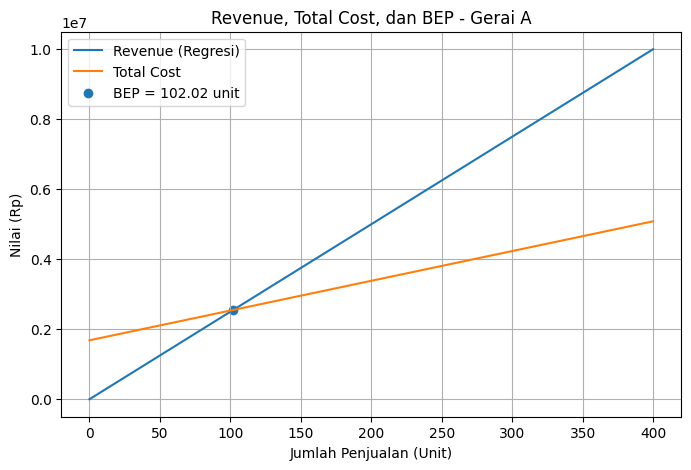

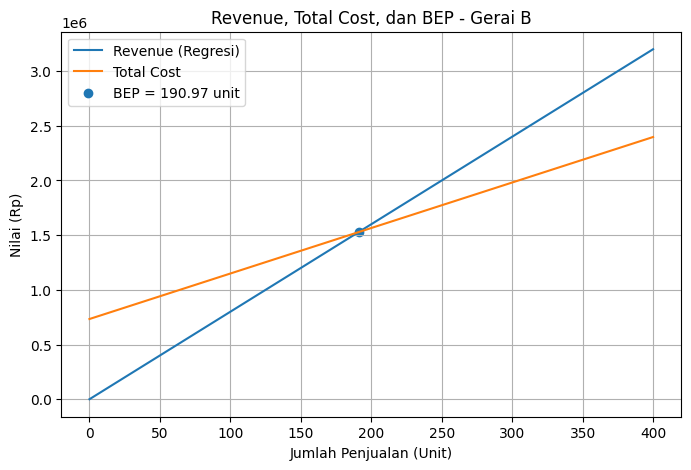

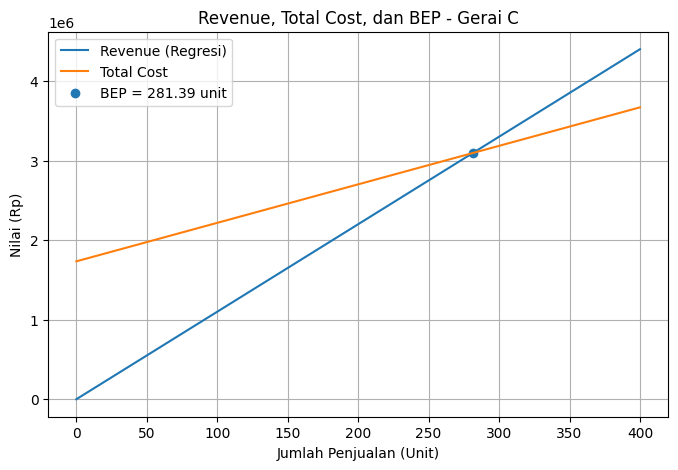

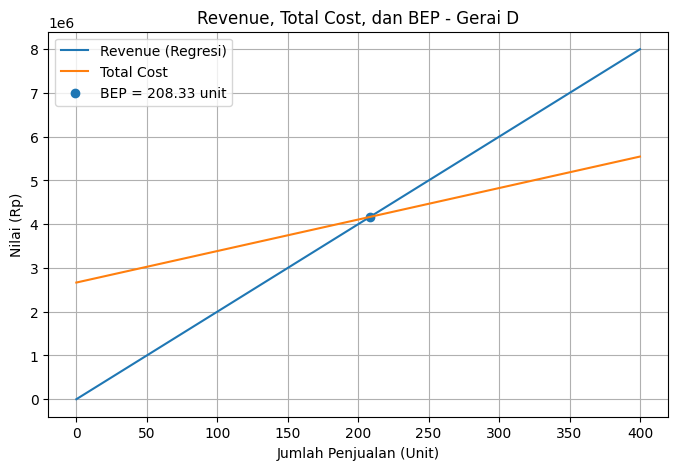

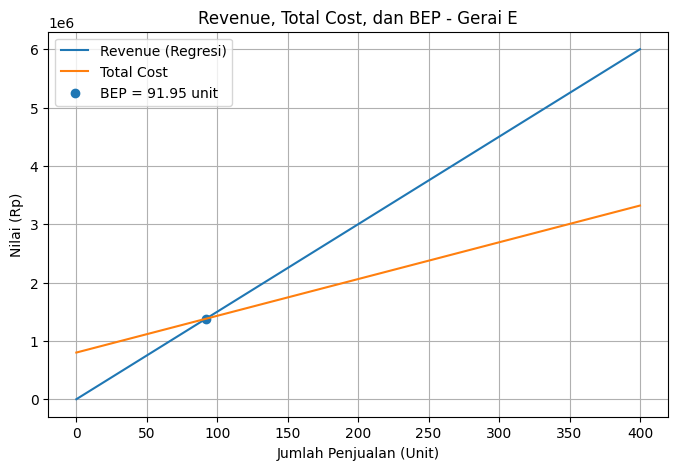

In [12]:
for _, r in hasil_regresi.iterrows():
    gerai = r["Gerai"]

    vc = biaya.loc[biaya["Gerai"] == gerai, "VC per Unit"].iloc[0]
    fc = biaya.loc[biaya["Gerai"] == gerai, "Fixed Cost"].iloc[0]

    bep = hasil_bep.loc[
        hasil_bep["Gerai"] == gerai, "BEP (Unit)"
    ].iloc[0]

    x = np.linspace(0, max(400, bep * 1.3), 100)

    revenue = r["Slope"] * x + r["Intercept"]
    total_cost = vc * x + fc

    plt.figure(figsize=(8, 5))
    plt.plot(x, revenue, label="Revenue (Regresi)")
    plt.plot(x, total_cost, label="Total Cost")
    plt.scatter(bep, r["Slope"] * bep + r["Intercept"],
                label=f"BEP = {bep:.2f} unit")

    plt.xlabel("Jumlah Penjualan (Unit)")
    plt.ylabel("Nilai (Rp)")
    plt.title(f"Revenue, Total Cost, dan BEP - {gerai}")
    plt.legend()
    plt.grid(True)
    plt.show()

Grafik menunjukkan posisi BEP sebagai titik perpotongan antara revenue hasil regresi dan total cost. Di bawah titik tersebut, model menunjukkan revenue belum menutup seluruh biaya. Setelah melewati titik BEP, revenue model berada di atas total cost sehingga selisihnya menjadi positif.

## 8. Kesimpulan

Secara umum, jumlah penjualan memiliki hubungan positif dengan revenue pada kelima gerai. Regresi linear digunakan karena pola data menunjukkan kecenderungan yang relatif lurus. Nilai R² membantu melihat seberapa baik model menjelaskan variasi revenue berdasarkan jumlah penjualan.

Selanjutnya, BEP ditentukan dengan membentuk selisih antara revenue hasil regresi dan total cost, kemudian mencari akar fungsi tersebut menggunakan metode Bisection. Hasil akhirnya menunjukkan jumlah unit penjualan yang perlu dicapai masing-masing gerai agar revenue model sama dengan total biaya.

Perbedaan BEP antar gerai dipengaruhi oleh pola revenue, biaya variabel per unit, dan fixed cost harian masing-masing gerai.